# ConvLSTM — Etapa 4: atacar el colapso a prediccion plana

**Diagnostico previo (Etapa 3):** el modelo entrenaba con MAE/RMSE razonables, pero la
prediccion autorregresiva de los 12 meses resulto ser practicamente una mancha uniforme
(casi sin variacion mes a mes ni contraste interno), mientras que los mapas reales tienen
un pico bien marcado. IoU y PAI daban 0.0000 porque el "10% mas denso" de un mapa casi
plano no tiene relacion real con donde esta el hotspot verdadero. Esto se confirmo
visualmente: ya desde el Mes 1 la prediccion sale plana, asi que NO es acumulacion de
error autorregresivo -- es que el modelo nunca aprendio el patron espacial.

**Hipotesis de causa raiz:** el MSE plano, sobre un mapa donde la mayoria de los pixeles
son fondo (valores bajos) y solo un puñado son el hotspot real, se minimiza barato
prediciendo algo cercano al promedio general. Con dropout/recurrent_dropout=0.3 y pocos
datos de entrenamiento (~41 secuencias), el modelo tiene todavia mas incentivo a
"conformarse" con esa solucion plana en vez de arriesgarse a aprender el pico.

## Los 3 cambios de esta etapa (los tres juntos, para maximizar la señal del experimento)

1. **Perdida ponderada por densidad real** (la mas importante): en vez de MSE plano, se
   penaliza mas fuerte el error en las celdas que en la realidad tienen mayor densidad de
   crimen. Esto le quita al modelo el incentivo de "hacer trampa" con el promedio.
2. **Menos regularizacion**: dropout y recurrent_dropout bajan de 0.3 a 0.1, y L2 baja de
   1e-4 a 1e-5. Con tan pocos datos, tanta regularizacion empuja al modelo hacia la
   solucion mas "segura" (plana) en vez de dejarlo ajustar el pico.
3. **Transformacion log1p antes de normalizar**: los valores de densidad KDE son muy
   sesgados (la mayoria de los pixeles cerca de 0, un pico raro y alto). Al normalizar
   linealmente (dividir entre el maximo), casi todos los pixeles de fondo quedan
   aplastados cerca de 0, dandole al modelo muy poca señal de gradiente en esa zona.
   `log1p` comprime el pico extremo y "estira" el rango medio-bajo, dando mas textura
   informativa a todo el mapa (no solo al pico).

**Que se mantiene igual (para no perder de vista que estos 3 cambios fueron los que
causaron cualquier mejora):** arquitectura (4 capas, 37 filtros), n_frames=12,
target_shape=(90,124), split 80/20, batch_size=11, epochs=50, el fix de orden cronologico
de la Etapa 3, y todos los demas parametros que siguen sin estar formalmente justificados
(ver checklist al final).

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
 #Para comprobar el tipo de GPU asignada a nuestro portatil, utilizamos el siguiente comando.
!nvidia-smi

Fri Jul 24 18:24:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# ============================================================================
# 1. CONFIGURACION Y PARAMETROS
# ============================================================================
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, Conv3D, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.ndimage import zoom
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import glob
import os
import re
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ======================================================
# OPTIMIZACION GPU PARA GOOGLE COLAB
# ======================================================
from tensorflow.keras import backend as K
K.clear_session()
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU configurada con memory growth habilitado")
    except RuntimeError as e:
        print(e)

GPU configurada con memory growth habilitado


## Parametros

Los que traen `# MEJORA:` siguen sin estar justificados por un experimento propio (se
heredan del repo original). Los que traen `# ETAPA 4:` son los 3 cambios nuevos de esta
corrida, con su razonamiento explicado.

In [ ]:
# ======================================================
# PARAMETROS DE ENTRADA Y SALIDA
# ======================================================
print("\nConfigurando rutas de salida y entrada de datos ...")

# AJUSTA ESTAS DOS RUTAS a donde tengas tus carpetas en Drive:
ruta_rasters = '/content/drive/MyDrive/Raster_nuevo/kde_200_5m_*.tif'
ruta_salida = '/content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_v3_etapa4/'

# Es lo que soporta colab
target_shape = (90, 124)
row, col = target_shape

# razonable por estacionalidad
n_frames = 12

test_size = 0.2
val_size = 0.1

# MEJORA: siguen sin estar justificados por un barrido de hiperparametros.
batch_size = 11
epochs = 50
num_capas = 4

# MEJORA: threshold_percentage=10 (top 10% = hotspot)
# nunca se probo sensibilidad (5%, 15%, 20%).
threshold_percentage = 10

# ======================================================
# ETAPA 4 -- Cambio 2: menos regularizacion
# ======================================================
# Antes: dropout=0.3, recurrent_dropout=0.3, l2=1e-4 (heredado del original, sin
# justificar). Con solo ~41 secuencias de entrenamiento, esa regularizacion es agresiva
# y probablemente empuja al modelo hacia la solucion "plana" (mas facil de regularizar
# que un pico marcado). Se bajan a valores mas conservadores; siguen siendo candidatos a
# una busqueda sistematica despues, no son "el valor correcto", solo un punto de partida
# menos restrictivo.
DROPOUT_RATE = 0.1        # antes 0.3
RECURRENT_DROPOUT_RATE = 0.1  # antes 0.3
L2_REG = 1e-5              # antes 1e-4

# ======================================================
# ETAPA 4 -- Cambio 1: peso de la perdida ponderada
# ======================================================
# ALPHA controla cuanto mas se penaliza el error en celdas de alta densidad real vs.
# celdas de fondo. Con ALPHA=0 la perdida ponderada se reduce a un MSE normal (sirve
# para comparar). ALPHA=5.0 es un punto de partida razonable (celdas con densidad
# maxima=1.0 pesan 6x mas que celdas de fondo con densidad=0), pero NO esta optimizado
# -- es candidato directo a barrido en una Etapa 5 si hace falta.
ALPHA_PERDIDA_PONDERADA = 5.0

# ======================================================
# ETAPA 4 -- Cambio 3: log-transform
# ======================================================
USAR_LOG_TRANSFORM = True  # poner en False para comparar contra la normalizacion lineal original

os.makedirs(ruta_salida, exist_ok=True)
print("\nConfigurado OK")


Configurando rutas de salida y entrada de datos ...

Configurado OK


## Funciones auxiliares

Incluye el fix de orden cronologico de la Etapa 3 (`extraer_year_month` + sort numerico
en vez de alfabetico), mas los 3 cambios de esta etapa, cada uno comentado en el punto
exacto donde ocurre.

In [ ]:
# ============================================================================
# 2. FUNCIONES AUXILIARES
# ============================================================================

def extraer_year_month(nombre_archivo):
    '''Extrae (year, month) del nombre del archivo para ordenar cronologicamente
    en vez de alfabeticamente (fix de la Etapa 3 -- sorted() alfabetico mezclaba
    el orden real porque los meses no llevan cero a la izquierda).'''
    m = re.search(r'_(\d{4})_(\d{1,2})\.tif$', nombre_archivo)
    if not m:
        raise ValueError(f"No se pudo extraer year/month de: {nombre_archivo}")
    year, month = int(m.group(1)), int(m.group(2))
    return (year, month)


def cargar_y_redimensionar_rasters(ruta_rasters, target_shape, usar_log=True):
    '''
    Carga y redimensiona las imagenes raster.

    ETAPA 4 -- Cambio 3 (log-transform): antes de normalizar por el maximo, se aplica
    log1p a cada imagen. Por que: los valores de densidad KDE son muy sesgados (la
    inmensa mayoria de las celdas cerca de 0, un puñado de celdas con valores mucho mas
    altos en el hotspot). Si se normaliza linealmente (dividir entre el maximo) sin mas,
    casi todas las celdas de fondo terminan con valores minusculos y casi identicos entre
    si -- le dan al modelo muy poco gradiente util para diferenciarlas. log1p "estira" el
    rango medio-bajo y comprime el pico extremo, dejando mas textura aprovechable en todo
    el mapa (no solo en el pico).

    log1p(x) = ln(1 + x) -- se usa log1p y no log(x) directo porque log(0) no esta
    definido y aqui SI hay celdas con densidad exactamente 0.
    '''
    print("Cargando y redimensionando rasters...")
    rasters = glob.glob(ruta_rasters)
    if len(rasters) == 0:
        raise ValueError(f"No se encontraron archivos en la ruta: {ruta_rasters}")

    # Fix de orden cronologico (Etapa 3): ordenar por (year, month) real, no alfabetico.
    rasters = sorted(rasters, key=extraer_year_month)

    print("Orden de los primeros archivos (verificar que sea cronologico):")
    for r in rasters[:15]:
        print(f"  {extraer_year_month(r)}  ->  {os.path.basename(r)}")

    sequences = []
    for i, raster in enumerate(rasters):
        try:
            with rasterio.open(raster) as src:
                image = src.read(1)
                zoom_factors = (target_shape[0] / image.shape[0], target_shape[1] / image.shape[1])
                resized_image = zoom(image, zoom_factors, order=1)
                sequences.append(resized_image)
        except Exception as e:
            print(f"Error procesando {raster}: {e}")
            continue

    sequences = np.array(sequences, dtype=np.float32)

    # --- ETAPA 4, Cambio 3: log-transform ANTES de normalizar por el maximo ---
    if usar_log:
        sequences = np.log1p(sequences)
        print("Log-transform (log1p) aplicado antes de normalizar.")

    sequences = sequences / sequences.max()
    print(f"Cargadas {len(sequences)} imagenes de tamano {target_shape}")
    print(f"Rango final tras normalizar: min={sequences.min():.4f}  max={sequences.max():.4f}  media={sequences.mean():.4f}")
    return sequences


def dividir_datos_temporales(sequences, test_size=0.2):
    '''Divide los datos manteniendo el orden temporal (sin cambios vs. Etapa 3).'''
    n_total = len(sequences)
    n_test = int(n_total * test_size)
    train_sequences = sequences[:-n_test]
    test_sequences = sequences[-n_test:]
    print(f"Division temporal: {len(train_sequences)} para entrenamiento, {len(test_sequences)} para test")
    return train_sequences, test_sequences


def generar_secuencias(sequences, n_frames=12):
    '''Genera secuencias de entrada (X) y objetivo (y) para ConvLSTM (sin cambios).'''
    n_samples = sequences.shape[0] - n_frames
    if n_samples <= 0:
        raise ValueError(f"No hay suficientes frames. Se necesitan al menos {n_frames + 1} frames.")
    print(f'Generando {n_samples} secuencias de {n_frames} frames cada una')

    X = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    y = np.zeros((n_samples, n_frames, sequences.shape[1], sequences.shape[2], 1), dtype=np.float32)
    for i in range(n_samples):
        X[i, :, :, :, 0] = sequences[i:i + n_frames]
        y[i, :, :, :, 0] = sequences[i + 1:i + n_frames + 1]
    return X, y


def crear_perdida_ponderada(alpha=5.0):
    '''
    ETAPA 4 -- Cambio 1 (el mas importante): perdida MSE ponderada por densidad real.

    La perdida normal (MSE) trata cada pixel igual, sin importar si es una celda de
    fondo o el centro del hotspot. Con un mapa donde ~90% de los pixeles son fondo, el
    optimizador puede "ganar" mucho MSE con solo acertar el fondo, y le sale barato
    ignorar el pico -- eso es justo lo que vimos: el modelo predijo una mancha plana.

    Esta funcion multiplica el error al cuadrado de cada pixel por un peso que crece
    con la densidad REAL de ese pixel:

        peso(pixel) = 1 + alpha * y_true(pixel)

    Con alpha=5 y y_true en [0,1] (ya normalizado), un pixel de fondo (y_true=0) pesa 1x,
    y un pixel en el centro del hotspot (y_true=1) pesa 6x. Esto le da al optimizador un
    incentivo real para acertar el pico, no solo el fondo.

    alpha=0 reduce esta funcion a un MSE normal (util para comparar A/B).
    '''
    def perdida_ponderada(y_true, y_pred):
        peso = 1.0 + alpha * y_true
        error_cuadrado = tf.square(y_true - y_pred)
        return tf.reduce_mean(peso * error_cuadrado)
    return perdida_ponderada


def crear_modelo_convlstm(input_shape, num_capas=4, dropout_rate=0.3,
                           recurrent_dropout_rate=0.3, l2_reg=1e-4):
    '''Crea el modelo ConvLSTM. Misma arquitectura que el original (4 capas,
    37 filtros, BatchNormalization activa, Conv3D final sigmoide) -- lo unico
    que cambia son los valores de dropout/recurrent_dropout/l2 (Etapa 4, Cambio 2),
    ahora parametrizados en vez de estar fijos adentro de la funcion.'''
    model = Sequential()
    for i in range(num_capas):
        return_sequences = True
        model.add(ConvLSTM2D(
            # MEJORA: filters=37 y kernel_size=3x3 siguen sin barrido de hiperparametros.
            filters=37,
            kernel_size=(3, 3),
            input_shape=input_shape if i == 0 else None,
            padding='same',
            return_sequences=return_sequences,
            dropout=dropout_rate,
            recurrent_dropout=recurrent_dropout_rate,
            kernel_regularizer=l2(l2_reg),
            recurrent_regularizer=l2(l2_reg)
        ))
        if i < num_capas - 1:
            model.add(BatchNormalization())

    model.add(Conv3D(filters=1, kernel_size=(3, 3, 3), activation='sigmoid', padding='same'))
    return model

In [ ]:
# ============================================================================
# 3. CARGA Y PREPROCESAMIENTO
# ============================================================================
sequences = cargar_y_redimensionar_rasters(ruta_rasters, target_shape, usar_log=USAR_LOG_TRANSFORM)
print(f"Tamano de la secuencia: {sequences.shape}")
print(f"Tipo de datos: {sequences.dtype}")
print("Configurando datos train y test")
train_sequences, test_sequences = dividir_datos_temporales(sequences, test_size)
X_train, y_train = generar_secuencias(train_sequences, n_frames)
X_test, y_test = generar_secuencias(test_sequences, n_frames)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

Cargando y redimensionando rasters...
Orden de los primeros archivos (verificar que sea cronologico):
  (2018, 1)  ->  kde_200_5m_2018_1.tif
  (2018, 2)  ->  kde_200_5m_2018_2.tif
  (2018, 3)  ->  kde_200_5m_2018_3.tif
  (2018, 4)  ->  kde_200_5m_2018_4.tif
  (2018, 5)  ->  kde_200_5m_2018_5.tif
  (2018, 6)  ->  kde_200_5m_2018_6.tif
  (2018, 7)  ->  kde_200_5m_2018_7.tif
  (2018, 8)  ->  kde_200_5m_2018_8.tif
  (2018, 9)  ->  kde_200_5m_2018_9.tif
  (2018, 10)  ->  kde_200_5m_2018_10.tif
  (2018, 11)  ->  kde_200_5m_2018_11.tif
  (2018, 12)  ->  kde_200_5m_2018_12.tif
  (2019, 1)  ->  kde_200_5m_2019_1.tif
  (2019, 2)  ->  kde_200_5m_2019_2.tif
  (2019, 3)  ->  kde_200_5m_2019_3.tif
Log-transform (log1p) aplicado antes de normalizar.
Cargadas 72 imagenes de tamano (90, 124)
Rango final tras normalizar: min=0.0000  max=1.0000  media=0.0921
Tamano de la secuencia: (72, 90, 124)
Tipo de datos: float32
Configurando datos train y test
Division temporal: 58 para entrenamiento, 14 para test


In [ ]:
# ============================================================================
# 4. MODELO Y CALLBACKS
# ============================================================================
input_shape = (n_frames, row, col, 1)
model = crear_modelo_convlstm(
    input_shape, num_capas,
    dropout_rate=DROPOUT_RATE,
    recurrent_dropout_rate=RECURRENT_DROPOUT_RATE,
    l2_reg=L2_REG,
)

# ETAPA 4 -- Cambio 1: se usa la perdida ponderada en vez de 'mse' plano.
# metrics=['mae'] se deja igual para poder seguir comparando MAE directamente contra
# las corridas anteriores (el MAE que se reporta NO esta ponderado, es el mismo calculo
# de siempre -- solo la funcion que se OPTIMIZA durante el entrenamiento cambia).
perdida = crear_perdida_ponderada(alpha=ALPHA_PERDIDA_PONDERADA)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),  # MEJORA: lr no barrido
              loss=perdida,
              metrics=['mae'])

model.summary()

checkpoint_cb = ModelCheckpoint(
    filepath=os.path.join(ruta_salida, 'mejor_modelo.keras'),
    save_best_only=True,
    monitor='val_loss',
    mode='min',
    verbose=1
)
earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,  # MEJORA: no justificado por que 5 y no 10
    restore_best_weights=True,
    verbose=1
)
reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,  # MEJORA: idem, no justificado
    min_lr=1e-6,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_lstm2d (ConvLSTM2D)        │ (None, 12, 90, 124,    │        50,764 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_2 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 90, 124,    │           148 │
│ (BatchNormalization)            │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_3 (ConvLSTM2D)      │ (None, 12, 90, 124,    │        98,716 │
│                                 │ 37)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 12, 90, 124, 1) │         1,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,356 (1.33 MB)

 Trainable params: 348,134 (1.33 MB)

 Non-trainable params: 222 (888.00 B)

In [ ]:
# ============================================================================
# 5. ENTRENAMIENTO
# ============================================================================
history = model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=val_size,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=2
)

Epoch 1/50

Epoch 1: val_loss improved from None to 0.23328, saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_v3_etapa4/mejor_modelo.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_v3_etapa4/mejor_modelo.keras
4/4 - 77s - 19s/step - loss: 0.2089 - mae: 0.3757 - val_loss: 0.2333 - val_mae: 0.4072 - learning_rate: 1.0000e-04
Epoch 2/50

Epoch 2: val_loss improved from 0.23328 to 0.23209, saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_v3_etapa4/mejor_modelo.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Taller de Complejidad/Perimetro A-B/RNN LSTMConv/output_v3_etapa4/mejor_modelo.keras
4/4 - 8s - 2s/step - loss: 0.1494 - mae: 0.3115 - val_loss: 0.2321 - val_mae: 0.4061 - learning_rate: 1.0000e-04
Epoch 3/50

Epoch 3: val_loss improved from 0.23209 to 0.23009, saving model to /content/drive/MyDrive/Taller de 

Modelo guardado correctamente en formato .h5 y .keras


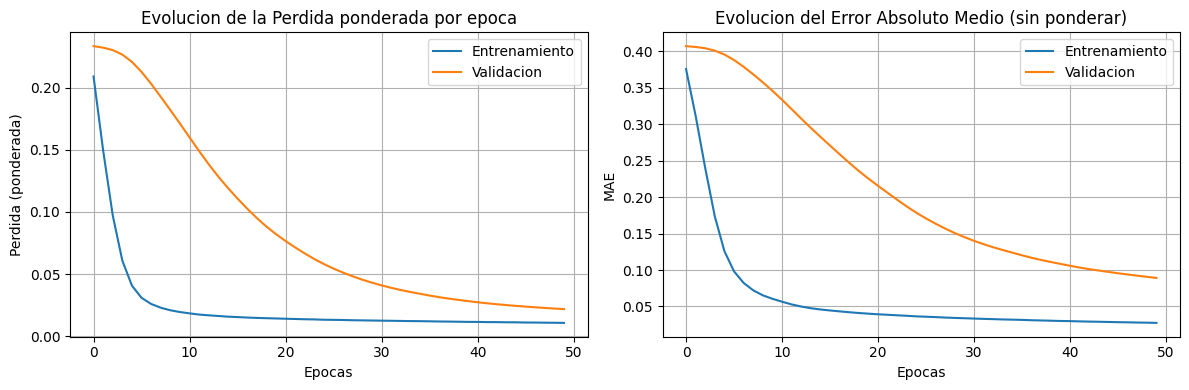

In [ ]:
# ============================================================================
# 6. GUARDADO Y VISUALIZACION
# ============================================================================
model.save(os.path.join(ruta_salida, 'modelo_final.h5'))
print("Modelo guardado correctamente en formato .h5 y .keras")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validacion')
plt.xlabel('Epocas'); plt.ylabel('Perdida (ponderada)')
plt.title('Evolucion de la Perdida ponderada por epoca')
plt.legend(); plt.grid(True)

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='Entrenamiento')
plt.plot(history.history['val_mae'], label='Validacion')
plt.xlabel('Epocas'); plt.ylabel('MAE')
plt.title('Evolucion del Error Absoluto Medio (sin ponderar)')
plt.legend(); plt.grid(True)

plt.tight_layout()
plt.savefig(f'{ruta_salida}entrenamiento_metricas.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# 7. EVALUACION GLOBAL
# ============================================================================
print("Realizando predicciones en conjunto de prueba...")
y_pred = model.predict(X_test, verbose=1)

# NOTA: mean_absolute_error/mean_squared_error de sklearn son el calculo ESTANDAR (sin
# ponderar), igual que en las corridas anteriores -- por eso se puede comparar directo
# contra los resultados previos (0.0918/0.1147 del original, 0.0846/0.1055 de Etapa 3),
# aunque el modelo se haya entrenado optimizando la perdida ponderada.
mae = mean_absolute_error(y_test.flatten(), y_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_test.flatten(), y_pred.flatten()))
print(f"\nMAE global: {mae:.4f}")
print(f"RMSE global: {rmse:.4f}")

Realizando predicciones en conjunto de prueba...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step

MAE global: 0.0854
RMSE global: 0.1063


In [ ]:
# ============================================================================
# 8. METRICAS ESPACIALES (funciones -- identicas a la Etapa 3, sin cambios)
# ============================================================================

def discretize_heatmap(heatmap, threshold_percentage):
    '''Convierte un mapa de calor continuo en un mapa binario de hotspots
    (top threshold_percentage% de celdas mas densas = 1).'''
    if not (0 < threshold_percentage <= 100):
        raise ValueError("El porcentaje del umbral debe estar entre 0 y 100.")
    threshold_value = np.percentile(heatmap, 100 - threshold_percentage)
    return (heatmap >= threshold_value).astype(int)


def calculate_iou(predicted_hotspots, true_hotspots):
    '''Intersection over Union entre dos mapas binarios de hotspots.'''
    intersection = np.sum((predicted_hotspots == 1) & (true_hotspots == 1))
    union = np.sum((predicted_hotspots == 1) | (true_hotspots == 1))
    if union == 0:
        return 1.0
    return intersection / union


def calculate_pai(predicted_hotspots, true_crime_locations):
    '''Predictive Accuracy Index = (%crimenes en hotspots) / (%area de hotspots).'''
    total_area = predicted_hotspots.size
    hotspot_area = np.sum(predicted_hotspots)
    if hotspot_area == 0:
        return 0.0
    percentage_area = hotspot_area / total_area
    total_crimes = len(true_crime_locations)
    if total_crimes == 0:
        return 0.0
    crimes_in_hotspots = 0
    for r, c in true_crime_locations:
        if 0 <= r < predicted_hotspots.shape[0] and 0 <= c < predicted_hotspots.shape[1]:
            if predicted_hotspots[r, c] == 1:
                crimes_in_hotspots += 1
    percentage_crimes = crimes_in_hotspots / total_crimes
    return percentage_crimes / percentage_area


print("Calculando metricas espaciales (un solo frame, igual que etapas anteriores)...")
true_map = y_test[-1, -1, :, :, 0]
pred_map = y_pred[-1, -1, :, :, 0]

true_hotspots = discretize_heatmap(true_map, threshold_percentage)
pred_hotspots = discretize_heatmap(pred_map, threshold_percentage)

iou = calculate_iou(pred_hotspots, true_hotspots)
print(f"IoU (un frame): {iou:.4f}")

true_crime_locations = np.argwhere(true_hotspots == 1)
pai = calculate_pai(pred_hotspots, true_crime_locations)
print(f"PAI (un frame): {pai:.4f}")

Calculando metricas espaciales (un solo frame, igual que etapas anteriores)...
IoU (un frame): 0.2270
PAI (un frame): 3.7007


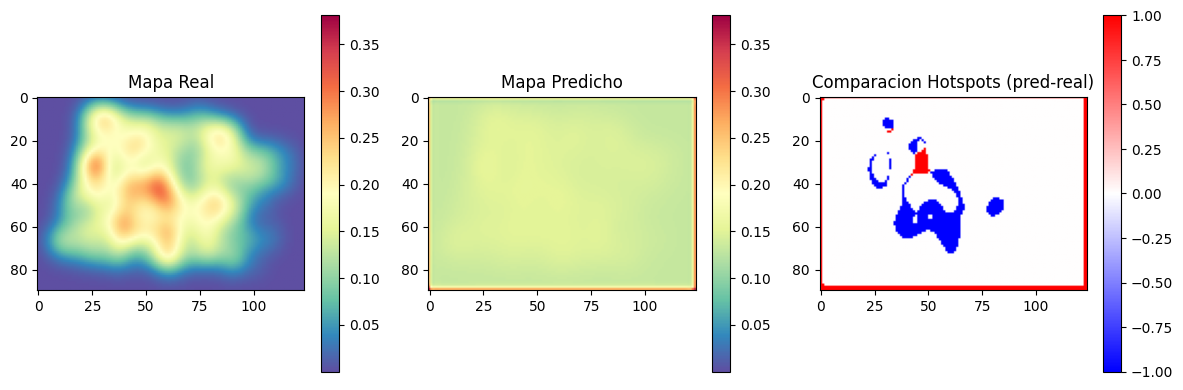

In [ ]:
# Visualizacion de comparacion CON ESCALA COMPARTIDA (fix aplicado desde el diagnostico
# de la Etapa 3 -- usar vmin/vmax independientes por panel disfraza que tan plana esta
# una prediccion; aqui ambos paneles usan el mismo rango real de referencia).
vmin_cmp = min(true_map.min(), pred_map.min())
vmax_cmp = max(true_map.max(), pred_map.max())

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(true_map, cmap='Spectral_r', vmin=vmin_cmp, vmax=vmax_cmp); plt.title('Mapa Real')
plt.colorbar()
plt.subplot(1,3,2)
plt.imshow(pred_map, cmap='Spectral_r', vmin=vmin_cmp, vmax=vmax_cmp); plt.title('Mapa Predicho')
plt.colorbar()
plt.subplot(1,3,3)
plt.imshow(pred_hotspots - true_hotspots, cmap='bwr', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Comparacion Hotspots (pred-real)')
plt.tight_layout()
plt.savefig(os.path.join(ruta_salida, '_map_real_predico_comparacion.png'), dpi=300, bbox_inches='tight')
plt.show()

## Prediccion autorregresiva de 12 meses

Mismo mecanismo que en Etapas anteriores: se toma la ultima secuencia de test como punto
de partida, se predice un mes, se agrega al final de la ventana (descartando el mas
antiguo), y se repite 12 veces.

In [ ]:
# ============================================================================
# 9. PREDICCION AUTORREGRESIVA DE 12 MESES (1 ANIO)
# ============================================================================
print("\nGenerando predicciones autorregresivas para 12 meses...")

track = X_test[-1].copy()
predicted_sequence = []

for j in range(12):
    new_pos = model.predict(track[np.newaxis, :, :, :, :], verbose=0)
    new_frame = new_pos[:, -1, :, :, :]
    predicted_sequence.append(new_frame[0])
    track = np.concatenate((track[1:], new_frame[0:1]), axis=0)

predicted_sequence = np.array(predicted_sequence)
print(f"Secuencia predicha con forma: {predicted_sequence.shape}")

for i in range(12):
    plt.figure(figsize=(6,4))
    plt.imshow(predicted_sequence[i, :, :, 0], cmap='Spectral_r',
               vmin=np.min(predicted_sequence), vmax=np.max(predicted_sequence))
    plt.title(f"Prediccion Mes {i+1}")
    plt.colorbar()
    plt.axis('off')
    plt.savefig(os.path.join(ruta_salida, f"prediccion_mes_{i+1}.png"), dpi=200, bbox_inches='tight')
    plt.close()


Generando predicciones autorregresivas para 12 meses...
Secuencia predicha con forma: (12, 90, 124, 1)


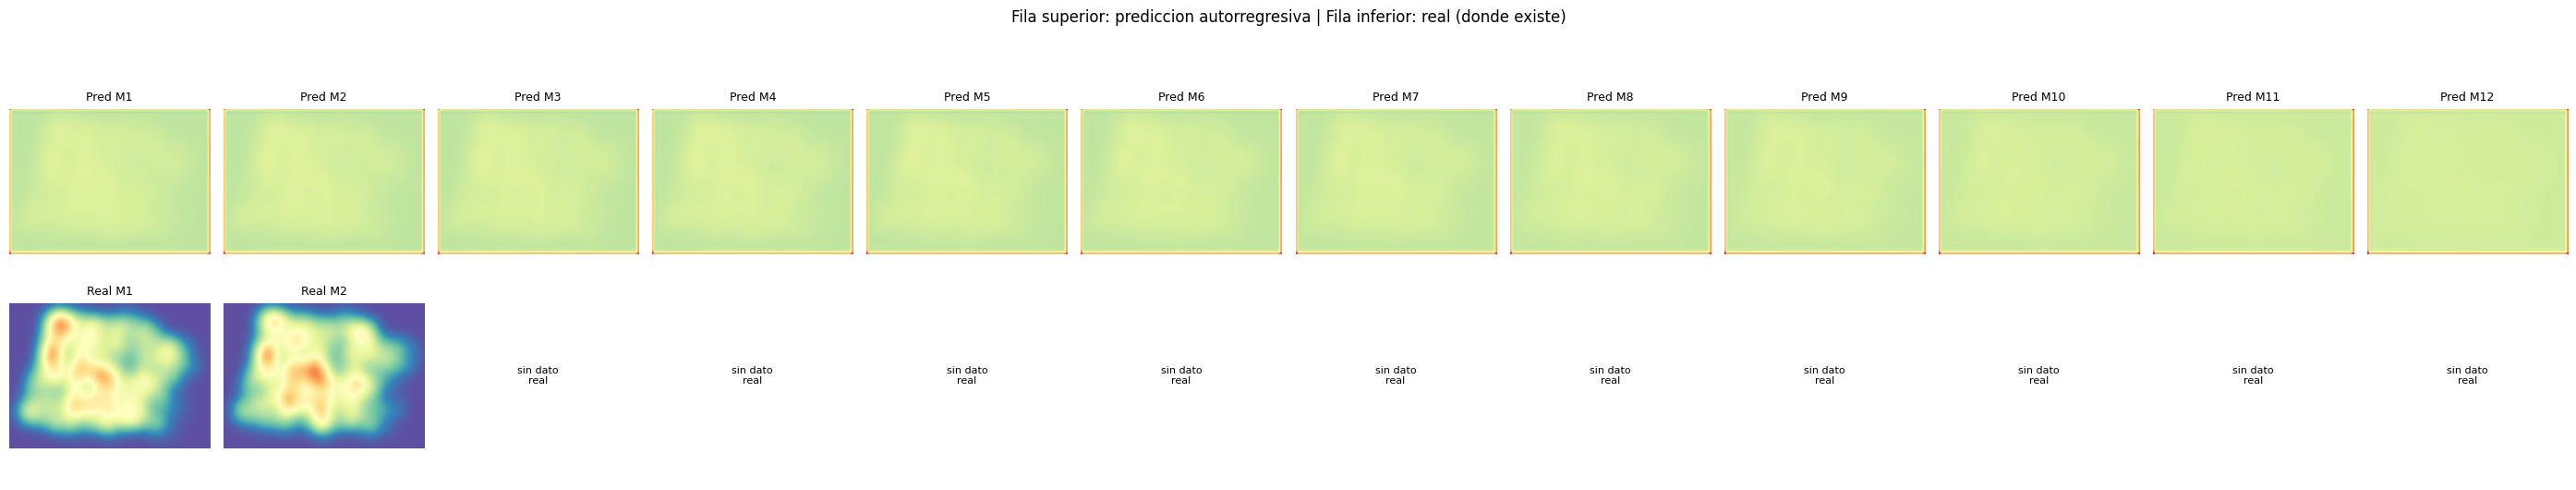

In [ ]:
# ============================================================================
# DIAGNOSTICO: comparacion mes a mes con escala de color COMPARTIDA
# (el mismo chequeo que confirmo el colapso plano en la Etapa 3 -- se repite aqui
# para verificar de un vistazo si con estos 3 cambios el modelo ya muestra textura
# y variacion real, o si sigue plano)
# ============================================================================
vmin_diag = min(y_test[:, -1, :, :, 0].min(), predicted_sequence[:, :, :, 0].min())
vmax_diag = max(y_test[:, -1, :, :, 0].max(), predicted_sequence[:, :, :, 0].max())

n_meses_con_real = min(12, y_test.shape[0])

fig, axes = plt.subplots(2, 12, figsize=(28, 5))
for i in range(12):
    axes[0, i].imshow(predicted_sequence[i, :, :, 0], cmap='Spectral_r', vmin=vmin_diag, vmax=vmax_diag)
    axes[0, i].set_title(f'Pred M{i+1}', fontsize=9)
    axes[0, i].axis('off')

    if i < n_meses_con_real:
        axes[1, i].imshow(y_test[i, -1, :, :, 0], cmap='Spectral_r', vmin=vmin_diag, vmax=vmax_diag)
        axes[1, i].set_title(f'Real M{i+1}', fontsize=9)
    else:
        axes[1, i].text(0.5, 0.5, 'sin dato\nreal', ha='center', va='center', fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Fila superior: prediccion autorregresiva | Fila inferior: real (donde existe)', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(ruta_salida, 'comparacion_12_meses_escala_compartida.png'), dpi=200, bbox_inches='tight')
plt.show()


Calculando metricas espaciales para cada mes predicho...

Metricas promedio en 2 mes(es) disponibles:
IoU medio: 0.2024
PAI medio: 3.3647


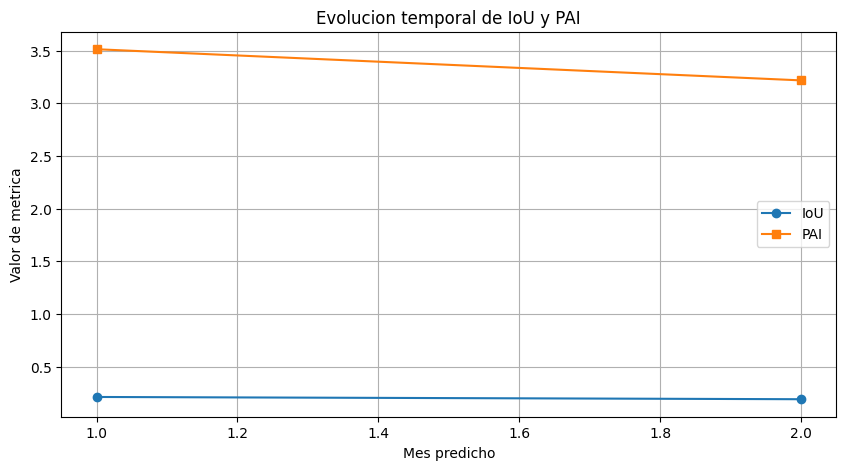

In [ ]:
# ============================================================================
# 10. METRICAS ESPACIALES -- EVALUACION TEMPORAL (12 meses)
# ============================================================================
print("\nCalculando metricas espaciales para cada mes predicho...")
ious, pais = [], []

for t in range(min(12, y_test.shape[0])):
    true_map_t = y_test[t, -1, :, :, 0]
    pred_map_t = predicted_sequence[t, :, :, 0]

    true_hotspots_t = discretize_heatmap(true_map_t, threshold_percentage)
    pred_hotspots_t = discretize_heatmap(pred_map_t, threshold_percentage)

    iou_t = calculate_iou(pred_hotspots_t, true_hotspots_t)
    ious.append(iou_t)

    true_crime_locations_t = np.argwhere(true_hotspots_t == 1)
    pai_t = calculate_pai(pred_hotspots_t, true_crime_locations_t)
    pais.append(pai_t)

iou_mean = np.mean(ious)
pai_mean = np.mean(pais)
print(f"\nMetricas promedio en {len(ious)} mes(es) disponibles:")
print(f"IoU medio: {iou_mean:.4f}")
print(f"PAI medio: {pai_mean:.4f}")

plt.figure(figsize=(10,5))
plt.plot(range(1, len(ious)+1), ious, marker='o', label='IoU')
plt.plot(range(1, len(pais)+1), pais, marker='s', label='PAI')
plt.title('Evolucion temporal de IoU y PAI')
plt.xlabel('Mes predicho')
plt.ylabel('Valor de metrica')
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(ruta_salida, 'metricas_temporales.png'), dpi=300, bbox_inches='tight')
plt.show()

In [2]:
# ============================================================================
# 11. COMPARACION CONTRA TODAS LAS ETAPAS ANTERIORES
# ============================================================================
resultados_previos = {
    "Original (input2/)":       {"MAE": 0.0918, "RMSE": 0.1147, "IoU": 0.0196, "PAI": 0.3843},
    "Etapa 3 (input3/ + orden)": {"MAE": 0.0846, "RMSE": 0.1055, "IoU": 0.2882, "PAI": 4.4668},
}
resultado_actual = {"MAE": mae, "RMSE": rmse, "IoU": iou_mean, "PAI": pai_mean}

print(f"{'Metrica':<10}", end="")
for nombre in list(resultados_previos.keys()) + ["Etapa 4 (perdida+reg+log)"]:
    print(f"{nombre:<28}", end="")
print()

for k in ["MAE", "RMSE", "IoU", "PAI"]:
    print(f"{k:<10}", end="")
    for nombre, res in resultados_previos.items():
        print(f"{res[k]:<28.4f}", end="")
    print(f"{resultado_actual[k]:<28.4f}")

NameError: name 'mae' is not defined